# Anotación de DEGs de lubina (*Dicentrarchus labrax*)
## TFM — Biomarcadores transcriptómicos de eficiencia digestiva en dorada y lubina
### Autor: Ángel López Francés | Universidad de Murcia

---

## Objetivo de este notebook

El microarray usado en GSE59240 (Calduch-Giner et al., 2016) es un **array personalizado Agilent** (GPL18910) construido con la base de datos SeaBassDB del IATS-CSIC. Sus sondas tienen IDs internos (`L3_83747`, `L12_34593`...) que no son nombres de genes directamente.

En este notebook se realiza:
1. **Cruza** los DEGs con el archivo de anotación de la plataforma GPL18910 para obtener las secuencias de cada sonda
2. **Clasifica** los DEGs según su patrón de expresión a lo largo del intestino (ANT/MED/POS)
3. **Genera archivos FASTA** para hacer BLAST en NCBI y obtener los nombres de genes

**Archivos necesarios:**
- `DEGs_lubina_intestino.csv` — generado en el notebook `TFM_Lubina_Microarray.ipynb`
- `GPL18910_family.soft` — descargado desde https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL18910

**Referencia:**
Calduch-Giner, J. A., Sitjà-Bobadilla, A., & Pérez-Sánchez, J. (2016). Gene expression profiling reveals functional specialization along the intestinal tract of a carnivorous teleostean fish (*Dicentrarchus labrax*). *Frontiers in Physiology, 7*, 359. https://doi.org/10.3389/fphys.2016.00359

## 1. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

print(' Librerías importadas correctamente')

 Librerías importadas correctamente


## 2. Extracción de la tabla de anotación del archivo SOFT

El archivo SOFT de la plataforma GPL18910 contiene la tabla de anotación del microarray.
Tiene formato específico de GEO con marcadores `!platform_table_begin` y `!platform_table_end`.

Las columnas relevantes son:
- `ACCESSION_STRING` → ID de sonda que coincide con nuestros GeneIDs (ej: `L12_14278`)
- `SEQUENCE` → secuencia nucleotídica de la sonda (60 bp) para hacer BLAST

In [3]:
ruta_soft = 'c:\\Users\\angel\\Desktop\\datos tfm\\GPL18910_family.soft'

with open(ruta_soft, 'r', errors='replace') as f:
    lines = f.readlines()

# Localizar inicio y fin de la tabla de anotación
start, end = None, None
for i, line in enumerate(lines):
    if '!platform_table_begin' in line.lower():
        start = i + 1  # La tabla comienza en la siguiente línea
    if '!platform_table_end' in line.lower():
        end = i
        break

print(f'Tabla de plataforma encontrada: líneas {start} a {end}')
print(f'Total de sondas: {end - start - 1:,}')

# Parsear la tabla como DataFrame
tabla_str = ''.join(lines[start:end])
anotacion = pd.read_csv(io.StringIO(tabla_str), sep='\t')

# Crear columna GeneID que coincide con los IDs de nuestros DEGs
anotacion['GeneID'] = anotacion['ACCESSION_STRING']

print(f'\nColumnas disponibles: {anotacion.columns.tolist()}')
print(f'\nPrimeras filas:')
anotacion[['GeneID', 'SEQUENCE']].head(5)

Tabla de plataforma encontrada: líneas 72 a 14280
Total de sondas: 14,207

Columnas disponibles: ['ID', 'SPOT_ID', 'CONTROL_TYPE', 'ACCESSION_STRING', 'CHROMOSOMAL_LOCATION', 'SEQUENCE', 'GeneID']

Primeras filas:


,GeneID,SEQUENCE
0,L12_14278,AGGGAGGAGAGGGCAACAACTAAAGAGTCCAAAACCTCATTCTGCC...
1,L12_15072,GTTCAGAGTGAACGGGTTCCTGTTAGCGGCGCTGGCCGTTATAGGT...
2,L12_15957,TTAAAGCAAAGGAAAGAAGAGATGATCCAGCAGGCACGCAGGAGAT...
3,L12_17496,AGTTTGTCGAGGTTGTCGATAACGACTTTACCGATGAAAGCATGTA...
4,L12_17782,TCCAACTGGTTGACCTACAAGAGATTTCCATTCCTAGTGCCAAAGC...


## 3. Carga de los DEGs de lubina

Cargamos el archivo generado en el notebook `TFM_Lubina_Microarray.ipynb` con los genes diferencialmente expresados entre los tres segmentos intestinales.

In [5]:
# Cargar DEGs
degs = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\tablasygraficasyjupiters\\DEGs_lubina_intestino.csv', index_col=0)

# Calcular fold changes entre segmentos (en escala log2)
# FC positivo = mayor en ANT que en POS
degs['FC_ANT_vs_POS'] = degs['media_ANT'] - degs['media_POS']
degs['FC_MED_vs_POS'] = degs['media_MED'] - degs['media_POS']
degs['FC_ANT_vs_MED'] = degs['media_ANT'] - degs['media_MED']

print(f'DEGs totales (FDR<0.05): {len(degs):,}')
print(f'DEGs FDR<0.01: {(degs["padj"]<0.01).sum():,}')
print(f'DEGs FDR<0.001: {(degs["padj"]<0.001).sum():,}')
print(f'\nColumnas: {degs.columns.tolist()}')
degs.head()

DEGs totales (FDR<0.05): 4,613
DEGs FDR<0.01: 2,965
DEGs FDR<0.001: 1,635

Columnas: ['pvalue', 'padj', 'media_ANT', 'media_MED', 'media_POS', 'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED']


,pvalue,padj,media_ANT,media_MED,media_POS,FC_ANT_vs_POS,FC_MED_vs_POS,FC_ANT_vs_MED
GeneID,,,,,,,,
L3_83747,2.161623e-18,2.903515e-14,18.376787,18.373001,13.274004,5.102783,5.098997,0.003786
L2_28353,4.104778e-18,2.903515e-14,10.733166,10.727529,4.588352,6.144814,6.139177,0.005637
L12_34593,2.919123e-17,1.376561e-13,18.862050,18.858677,9.316545,9.545505,9.542132,0.003373
L12_84939,1.755821e-16,6.209901e-13,13.512638,13.367796,18.396969,-4.884331,-5.029173,0.144842
L12_89941,3.116161e-16,8.816866e-13,14.827564,14.611801,7.976256,6.851308,6.635545,0.215763


## 4. Clasificación de DEGs por patrón de expresión intestinal

Cada gen se clasifica según en qué segmento intestinal tiene mayor expresión:

- **Alto_ANT-MED**: genes con mayor expresión en intestino anterior y medio → relacionados con **digestión y absorción de nutrientes** (proteasas, lipasas, transportadores)
- **Alto_POS**: genes con mayor expresión en intestino posterior → relacionados con **transporte iónico, absorción de agua e inmunidad**
- **Uniforme**: genes sin gradiente claro de expresión a lo largo del eje intestinal

Distribución de patrones de expresión:
  Uniforme       : 3014 genes (65.3%)
  Alto_ANT-MED   :  834 genes (18.1%)
  Alto_POS       :  747 genes (16.2%)
  Alto_MED       :   11 genes (0.2%)
  Alto_ANT       :    7 genes (0.2%)


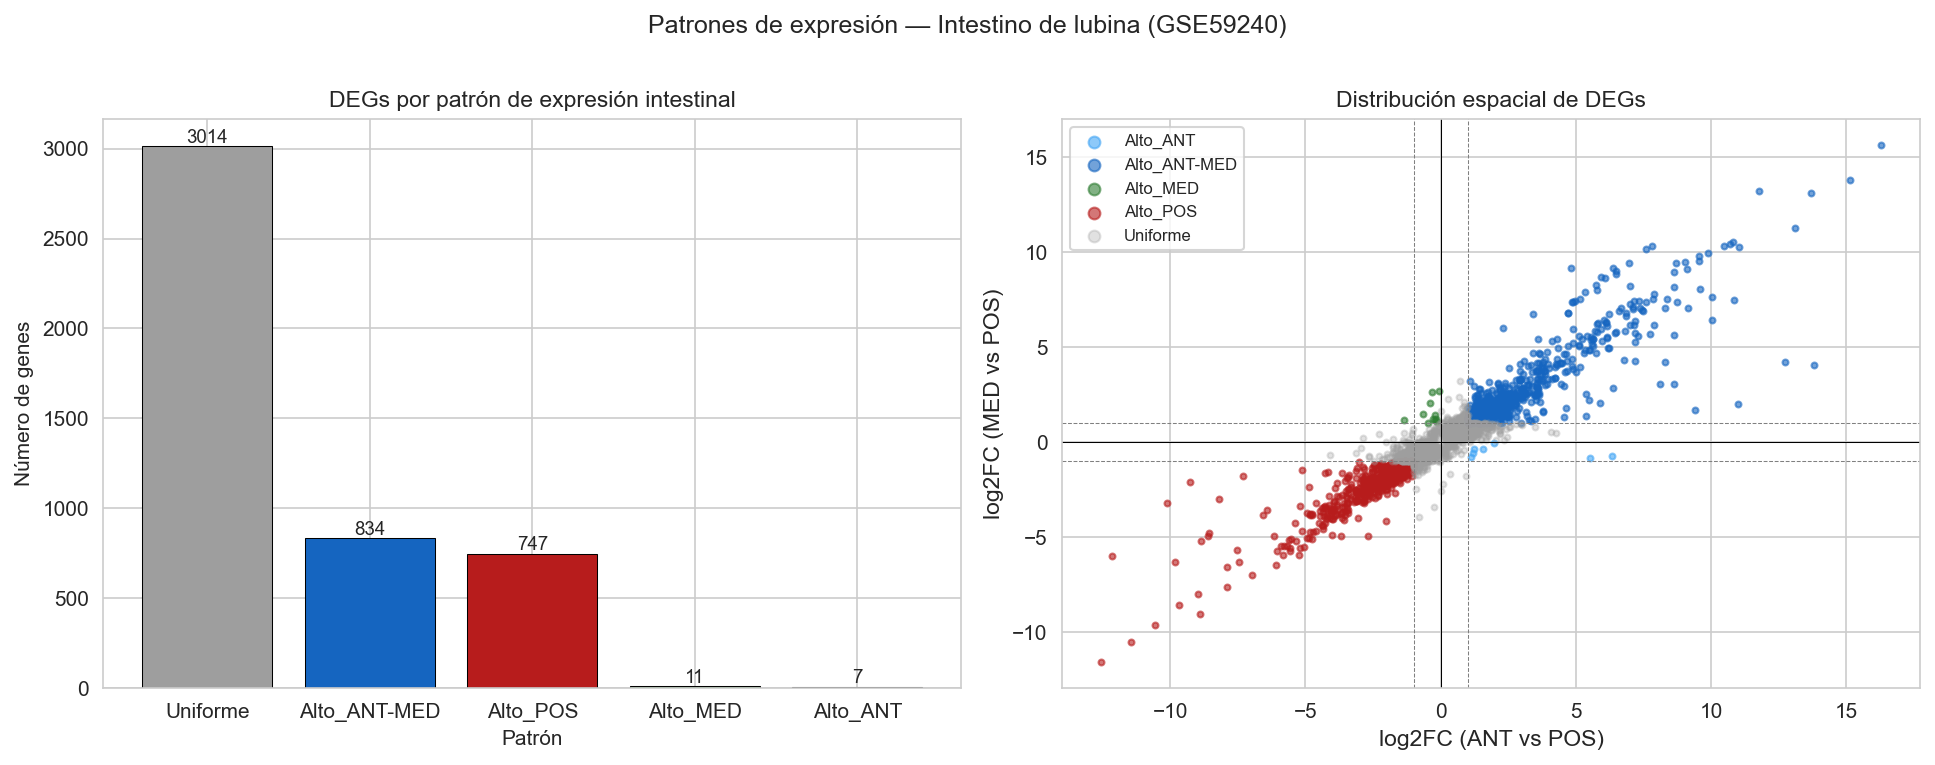

Figura guardada: Patrones_expresion_lubina.png


In [9]:
# Clasificar patrones de expresión
# Umbral de |log2FC| > 1 = cambio de al menos 2 veces
UMBRAL_FC = 1.0

def clasificar_patron(row):
    fc_ant_pos = row['FC_ANT_vs_POS']
    fc_med_pos = row['FC_MED_vs_POS']
    
    if fc_ant_pos > UMBRAL_FC and fc_med_pos > UMBRAL_FC:
        return 'Alto_ANT-MED'   # alto en anterior y medio
    elif fc_ant_pos < -UMBRAL_FC and fc_med_pos < -UMBRAL_FC:
        return 'Alto_POS'       # alto en posterior
    elif fc_ant_pos > UMBRAL_FC and fc_med_pos < 0:
        return 'Alto_ANT'       # gradiente decreciente ANT→POS
    elif fc_ant_pos < 0 and fc_med_pos > UMBRAL_FC:
        return 'Alto_MED'       # pico en medio
    else:
        return 'Uniforme'

degs['Patron'] = degs.apply(clasificar_patron, axis=1)

# Resumen
conteos = degs['Patron'].value_counts()
print('Distribución de patrones de expresión:')
for patron, n in conteos.items():
    pct = n/len(degs)*100
    print(f'  {patron:15s}: {n:4d} genes ({pct:.1f}%)')

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_patron = {
    'Alto_ANT-MED': '#1565C0',
    'Alto_POS':     '#B71C1C',
    'Alto_ANT':     '#42A5F5',
    'Alto_MED':     '#2E7D32',
    'Uniforme':     '#9E9E9E'
}

# Gráfico de barras
colores_barras = [colores_patron.get(p, '#9E9E9E') for p in conteos.index]
axes[0].bar(conteos.index, conteos.values, color=colores_barras,
            edgecolor='black', linewidth=0.5)
axes[0].set_title('DEGs por patrón de expresión intestinal', fontsize=11)
axes[0].set_ylabel('Número de genes')
axes[0].set_xlabel('Patrón')
for i, (p, n) in enumerate(conteos.items()):
    axes[0].text(i, n + 20, str(n), ha='center', fontsize=9)

# Scatter FC_ANT_vs_POS vs FC_MED_vs_POS
for patron, datos_p in degs.groupby('Patron'):
    color = colores_patron.get(patron, '#9E9E9E')
    alpha = 0.3 if patron == 'Uniforme' else 0.6
    axes[1].scatter(datos_p['FC_ANT_vs_POS'], datos_p['FC_MED_vs_POS'],
                    c=color, s=8, alpha=alpha, label=patron, rasterized=True)

axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].axhline(UMBRAL_FC, color='gray', linewidth=0.5, linestyle='--')
axes[1].axhline(-UMBRAL_FC, color='gray', linewidth=0.5, linestyle='--')
axes[1].axvline(UMBRAL_FC, color='gray', linewidth=0.5, linestyle='--')
axes[1].axvline(-UMBRAL_FC, color='gray', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('log2FC (ANT vs POS)', fontsize=11)
axes[1].set_ylabel('log2FC (MED vs POS)', fontsize=11)
axes[1].set_title('Distribución espacial de DEGs', fontsize=11)
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle('Patrones de expresión — Intestino de lubina (GSE59240)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('Patrones_expresion_lubina.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura guardada: Patrones_expresion_lubina.png')

## 5. Cruce con la anotación del array (GPL18910)

Cruzamos los DEGs con la tabla de anotación del SOFT para añadir las secuencias de cada sonda.
Estas secuencias son las que usaremos en el paso siguiente para identificar los genes mediante BLAST.

In [10]:
# Cruzar DEGs con secuencias del array
degs_anotados = degs.merge(
    anotacion[['GeneID', 'SEQUENCE']],
    left_index=True,
    right_on='GeneID',
    how='left'
).set_index('GeneID')

cobertura = degs_anotados['SEQUENCE'].notna().sum()
print(f'DEGs con secuencia asignada: {cobertura}/{len(degs_anotados)} ({cobertura/len(degs_anotados)*100:.1f}%)')
print(f'\nTabla final:')
degs_anotados[['padj', 'media_ANT', 'media_MED', 'media_POS',
               'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'Patron', 'SEQUENCE']].head(10)

DEGs con secuencia asignada: 4613/4613 (100.0%)

Tabla final:


,padj,media_ANT,media_MED,media_POS,FC_ANT_vs_POS,FC_MED_vs_POS,Patron,SEQUENCE
GeneID,,,,,,,,
L3_83747,2.903515e-14,18.376787,18.373001,13.274004,5.102783,5.098997,Alto_ANT-MED,CCACAACAATGTCATCAAGACCCTGAAGGAAAAAAGTAAAAATGTT...
L2_28353,2.903515e-14,10.733166,10.727529,4.588352,6.144814,6.139177,Alto_ANT-MED,AGCAAATGTCAGAGGCAAGCCAGATGCTGTTGGGATGATGAATTCG...
L12_34593,1.376561e-13,18.862050,18.858677,9.316545,9.545505,9.542132,Alto_ANT-MED,TACTTCGAGGAGATGAAGAACAAAATGACCCAGGACCTGACTGAGA...
L12_84939,6.209901e-13,13.512638,13.367796,18.396969,-4.884331,-5.029173,Alto_POS,GATGAATAGTACTGTATTCTGTATTGGTTCTAAGCGTGCGTGATTG...
L12_89941,8.816866e-13,14.827564,14.611801,7.976256,6.851308,6.635545,Alto_ANT-MED,GAATGTTTTCACCACCCAAATCGAGATACCTGACTTTGATGTTGAG...
L12_83830,1.420014e-12,10.798395,10.804590,16.361315,-5.562920,-5.556725,Alto_POS,GTCGGTGATTTCAAGATTAAGGCAGCTCAAAAGATCACCATCAAAA...
L12_88586,1.488748e-12,6.398986,6.521717,10.489650,-4.090664,-3.967933,Alto_POS,TTCCCAGTATACAAGTATGTCCCATATGGCCCTGTCAACGAGGTGA...
L12_84913,2.196596e-12,11.194633,11.154753,5.635489,5.559144,5.519264,Alto_ANT-MED,GTAAAACCGTTATGTTGACTTCGACAGTGGCTTTTTGTATTTTACG...
L12_85179,4.064441e-12,14.427741,14.483564,8.658461,5.769280,5.825103,Alto_ANT-MED,CCTCTCTTTGTTTGATGCTCTTTGGAATCTGTTGAGGTTAATAAAC...


## 6. Exportar tabla completa de DEGs anotados

In [11]:
# Guardar tabla completa con todos los campos
columnas_exportar = [
    'pvalue', 'padj',
    'media_ANT', 'media_MED', 'media_POS',
    'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED',
    'Patron', 'SEQUENCE'
]
degs_anotados[columnas_exportar].sort_values('padj').to_csv('DEGs_lubina_anotados.csv')

print(' Tabla guardada: DEGs_lubina_anotados.csv')
print(f'   Total DEGs: {len(degs_anotados):,}')
print(f'   Con secuencia: {degs_anotados["SEQUENCE"].notna().sum():,}')
print(f'\nDistribución por patrón:')
for patron, grp in degs_anotados.groupby('Patron'):
    print(f'   {patron:15s}: {len(grp):4d} genes')

 Tabla guardada: DEGs_lubina_anotados.csv
   Total DEGs: 4,613
   Con secuencia: 4,613

Distribución por patrón:
   Alto_ANT       :    7 genes
   Alto_ANT-MED   :  834 genes
   Alto_MED       :   11 genes
   Alto_POS       :  747 genes
   Uniforme       : 3014 genes


## 7. Generación de archivos FASTA para BLAST

El array GPL18910 es personalizado y no tiene nombres de genes en su anotación, solo secuencias de sondas de 60 pb. Usando BLAST podemos comparar estas secuencias contra bases de datos de proteínas (UniProtKB/SwissProt) o nucleótidos (RefSeq) para obtener el nombre del gen y su función.



In [12]:
def generar_fasta(df, patron_filtro, n_top, nombre_archivo, etiqueta):
    """
    Genera un archivo FASTA con las secuencias de los top N DEGs
    de un patrón de expresión dado.
    
    Parámetros:
    -----------
    df : DataFrame con DEGs anotados
    patron_filtro : str o list, patrón(es) a incluir
    n_top : int, número de genes top a incluir
    nombre_archivo : str, nombre del archivo de salida
    etiqueta : str, descripción para el encabezado FASTA
    """
    if isinstance(patron_filtro, list):
        subset = df[df['Patron'].isin(patron_filtro)]
    else:
        subset = df[df['Patron'] == patron_filtro]
    
    top = subset.dropna(subset=['SEQUENCE']).nsmallest(n_top, 'padj')
    
    fasta_lines = []
    for gid, row in top.iterrows():
        header = (f">{gid}|{etiqueta}"
                  f"|FC_ANT_POS={row['FC_ANT_vs_POS']:.2f}"
                  f"|FDR={row['padj']:.2e}")
        fasta_lines.append(header)
        fasta_lines.append(str(row['SEQUENCE']))
    
    with open(nombre_archivo, 'w') as f:
        f.write('\n'.join(fasta_lines))
    
    print(f' {nombre_archivo} — {len(top)} secuencias')
    return top

# FASTA 1: Genes alto en ANT-MED (digestión y absorción)
top_ant_med = generar_fasta(
    degs_anotados, 'Alto_ANT-MED', 100,
    'BLAST_lubina_AltoANT-MED.fasta',
    'AltoANT-MED_digestion-absorcion'
)

# FASTA 2: Genes alto en POS (transporte iónico, inmunidad)
top_pos = generar_fasta(
    degs_anotados, 'Alto_POS', 100,
    'BLAST_lubina_AltoPOS.fasta',
    'AltoPOS_transporte-ionico-inmunidad'
)

# FASTA 3: Top 50 DEGs más significativos (independiente del patrón)
top_general = generar_fasta(
    degs_anotados, list(degs_anotados['Patron'].unique()), 50,
    'BLAST_lubina_Top50_general.fasta',
    'Top50_MasSignificativos'
)

print('\nArchivos FASTA generados. Súbelos a NCBI BLAST para obtener nombres de genes.')

 BLAST_lubina_AltoANT-MED.fasta — 100 secuencias
 BLAST_lubina_AltoPOS.fasta — 100 secuencias
 BLAST_lubina_Top50_general.fasta — 50 secuencias

Archivos FASTA generados. Súbelos a NCBI BLAST para obtener nombres de genes.


## 8. Visualización: Heatmap por patrón de expresión

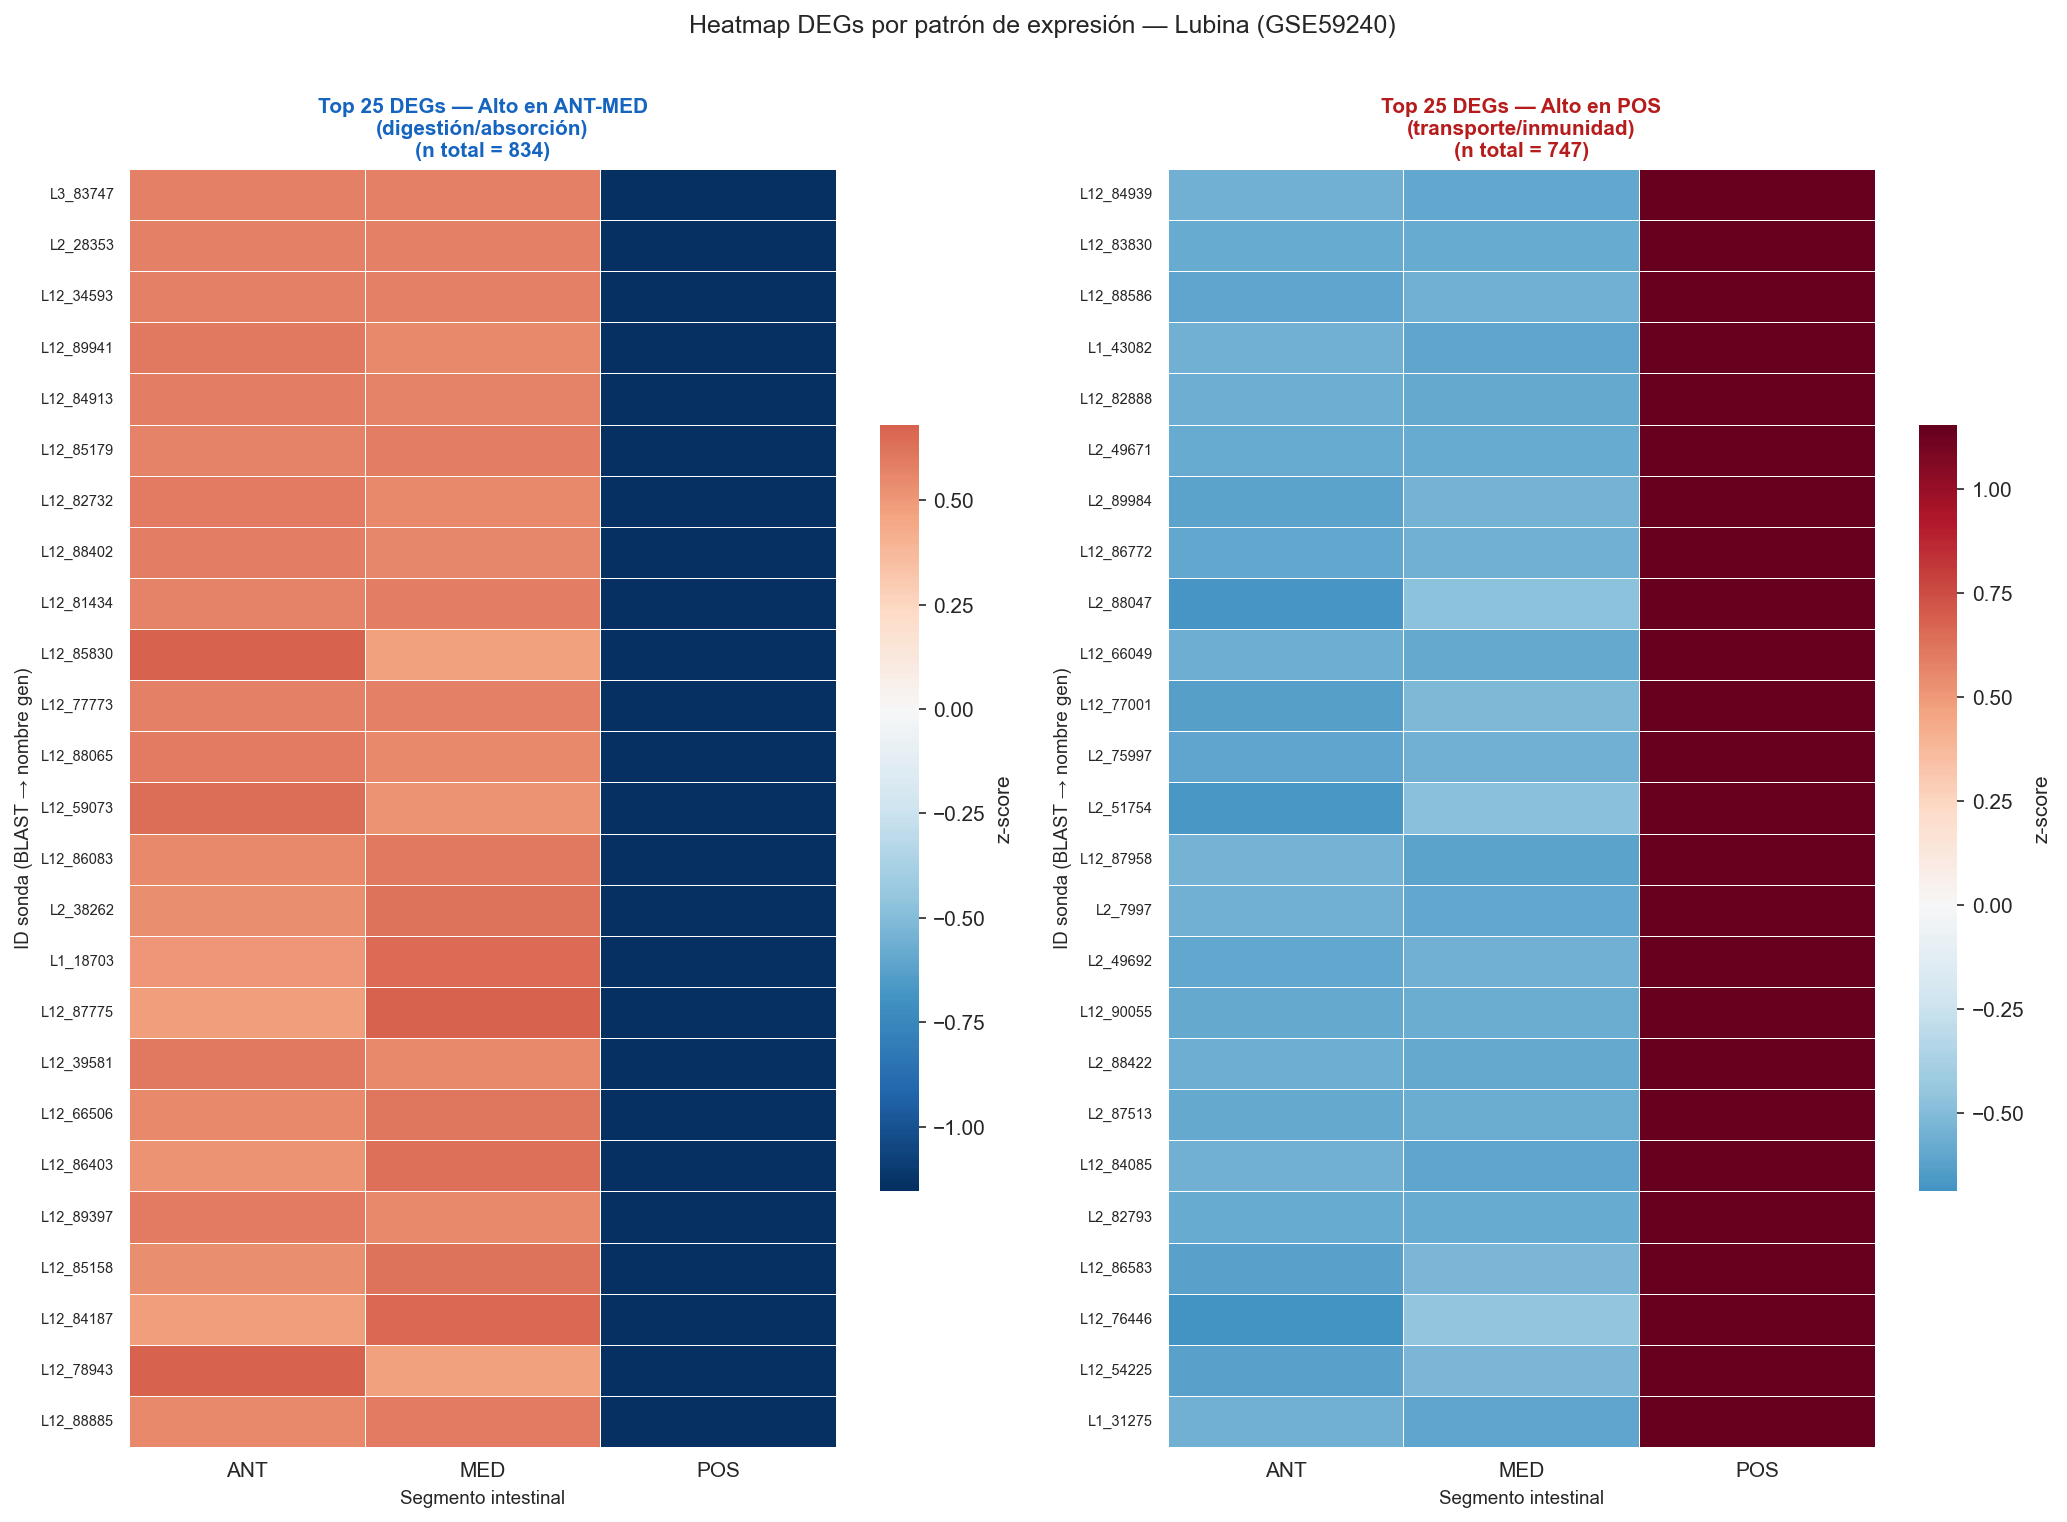

Figura guardada: Heatmap_patrones_lubina.png


In [13]:
# Heatmap de los top DEGs de cada patrón biológicamente relevante
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

for ax, (patron, titulo, color_barra) in zip(
    axes,
    [
        ('Alto_ANT-MED', 'Alto en ANT-MED\n(digestión/absorción)', '#1565C0'),
        ('Alto_POS',     'Alto en POS\n(transporte/inmunidad)',   '#B71C1C'),
    ]
):
    subset = degs_anotados[degs_anotados['Patron'] == patron].nsmallest(25, 'padj')
    
    # Matriz de medias por segmento
    heatmap_data = subset[['media_ANT', 'media_MED', 'media_POS']].copy()
    heatmap_data.columns = ['ANT', 'MED', 'POS']
    
    # Estandarizar por fila
    heatmap_z = heatmap_data.subtract(heatmap_data.mean(axis=1), axis=0)
    heatmap_z = heatmap_z.divide(heatmap_data.std(axis=1), axis=0)
    
    sns.heatmap(
        heatmap_z,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        yticklabels=True,
        xticklabels=True,
        linewidths=0.3,
        linecolor='white',
        cbar_kws={'label': 'z-score', 'shrink': 0.6}
    )
    ax.set_title(f'Top 25 DEGs — {titulo}\n(n total = {(degs_anotados["Patron"]==patron).sum()})',
                 fontsize=10, color=color_barra, fontweight='bold')
    ax.set_ylabel('ID sonda (BLAST → nombre gen)', fontsize=9)
    ax.set_xlabel('Segmento intestinal', fontsize=9)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Heatmap DEGs por patrón de expresión — Lubina (GSE59240)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('Heatmap_patrones_lubina.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: Heatmap_patrones_lubina.png')

In [14]:

blast_results = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\Z9HMPAJW014-Alignment-HitTable.csv',
     names=['query_id','subject_id','pct_identity','alignment_length',
            'mismatches','gap_opens','q_start','q_end','s_start','s_end',
            'evalue','bit_score','gene_name'])

#Filtrar hits de buena calidad
blast_filtrado = blast_results[
     (blast_results['pct_identity'] > 80) &
     (blast_results['evalue'] < 1e-5)
 ].drop_duplicates('query_id')

#Cruzar con DEGs anotados
degs_con_nombre = degs_anotados.merge(
     blast_filtrado[['query_id','gene_name','pct_identity','evalue']],
     left_index=True, right_on='query_id', how='left'
 )

#Exportar tabla final completa
degs_con_nombre.to_csv('DEGs_lubina_nombres_genes.csv')


## 10. Resumen del pipeline de anotación

| Paso | Herramienta | Descripción |
|------|-------------|-------------|
| 1 | Python/pandas | Extracción de tabla de anotación del SOFT (GPL18910) |
| 2 | Python/pandas | Cálculo de log2FC entre segmentos intestinales |
| 3 | Python | Clasificación por patrón de expresión (ANT-MED / POS / Uniforme) |
| 4 | Python | Cruce de DEGs con secuencias de sondas del array |
| 5 | Python | Generación de archivos FASTA para BLAST |
| 6 | NCBI BLAST | Identificación de genes a partir de secuencias de sondas |
| 7 | Python/Excel | Tabla comparativa dorada vs lubina |

**Archivos generados:**
- `DEGs_lubina_anotados.csv` — tabla completa con patrón y secuencia
- `BLAST_lubina_AltoANT-MED.fasta` — para BLAST: genes digestión/absorción
- `BLAST_lubina_AltoPOS.fasta` — para BLAST: genes transporte/inmunidad  
- `BLAST_lubina_Top50_general.fasta` — para BLAST: top 50 más significativos


In [15]:
# Información de sesión
import sys
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')

Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 12:58:53) [MSC v.1929 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.0.1
matplotlib: 3.10.6
seaborn: 0.13.2
